In [ ]:
# FLOOD DEPTH 

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Folder containing max flood depth rasters
raster_folder = r"E:\01. Project_deliverable\GIS\Flood_modeling_results\raster"

# Cypress Park boundary polygon
polygon_path = r"E:\01. Project_deliverable\GIS\Planning and Cadastre\Cypress_Park_boundaries\Cypress_Park_boundaries.shp"

In [3]:
# Threshold to define flooded cells (ft)
DEPTH_THRESHOLD_FT = 0.001

# Read polygon using Fiona to avoid pyogrio / PROJ issues
polygon_gdf = gpd.read_file(polygon_path, engine="fiona")

# Merge polygon geometries in case of multipart features
polygon_geom = [polygon_gdf.geometry.unary_union]

# Store polygon CRS to check consistency with rasters
poly_crs = polygon_gdf.crs
print("Polygon CRS:", poly_crs)

Polygon CRS: None


c:\Users\dveronez\AppData\Local\anaconda3\envs\general\Lib\site-packages\geopandas\array.py:334: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  self.crs = crs
c:\Users\dveronez\AppData\Local\anaconda3\envs\general\Lib\site-packages\geopandas\geodataframe.py:59: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  data.array.crs = crs
c:\Users\dveronez\AppData\Local\anaconda3\envs\general\Lib\site-packages\geopandas\geodataframe.py:407: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions de

In [4]:
# List all raster files in the folder
raster_files = glob.glob(os.path.join(raster_folder, "*.tif"))
print(f"Found {len(raster_files)} raster files.")

Found 6 raster files.


In [5]:
# Lists to store extracted depth values and corresponding raster names
all_values = []
raster_names = []


for raster_fp in raster_files:
    with rasterio.open(raster_fp) as src:

        

        # Clip raster to polygon extent
        # filled=False returns a masked array, preserving NoData correctly
        out_image, out_transform = mask(
            src,
            polygon_geom,
            crop=True,
            filled=False
        )

        # Extract first band (max flood depth)
        data = out_image[0]

        # Remove masked pixels (outside polygon or NoData)
        valid = data.compressed()

        # Keep only flooded cells based on threshold
        valid = valid[valid > DEPTH_THRESHOLD_FT]

        # Skip scenarios with no flooded cells inside the polygon
        if valid.size == 0:
            print(
                f"Warning: no flooded cells (> {DEPTH_THRESHOLD_FT} ft) "
                f"in {os.path.basename(raster_fp)}"
            )
            continue

        # Store values and raster name
        all_values.append(valid)
        raster_names.append(os.path.basename(raster_fp))

In [6]:
# Convert extracted values into long-format table for seaborn
values_list = []
labels_list = []

for vals, name in zip(all_values, raster_names):
    values_list.extend(vals.tolist())
    labels_list.extend([name] * len(vals))

df = pd.DataFrame({
    "Raster": labels_list,
    "Value": values_list
})

# Print raster names to confirm mapping before plotting
print("Current raster names:")
for i, name in enumerate(sorted(df["Raster"].unique()), 1):
    print(f"{i}. {name}")

Current raster names:
1. base_100yr_proc.tif
2. base_10yr_proc.tif
3. base_2y_proc.tif
4. future2070_100yr_proc.tif
5. future2070_10yr_proc.tif
6. future2070_2yr_proc.tif


In [7]:
# Mapping from file names to clean scenario labels for plots
name_mapping = {
    "base_2y_proc.tif": "Base - 2 Year",
    "base_10yr_proc.tif": "Base - 10 Year",
    "base_100yr_proc.tif": "Base - 100 Year",
    "future2070_2yr_proc.tif": "Future 2070 - 2 Year",
    "future2070_10yr_proc.tif": "Future 2070 - 10 Year",
    "future2070_100yr_proc.tif": "Future 2070 - 100 Year",
}

# Apply readable labels
df["Raster"] = df["Raster"].map(name_mapping).fillna(df["Raster"])

# Set categorical order so plots follow logical scenario order
plot_order = list(name_mapping.values())
df["Raster"] = pd.Categorical(
    df["Raster"],
    categories=plot_order,
    ordered=True
)




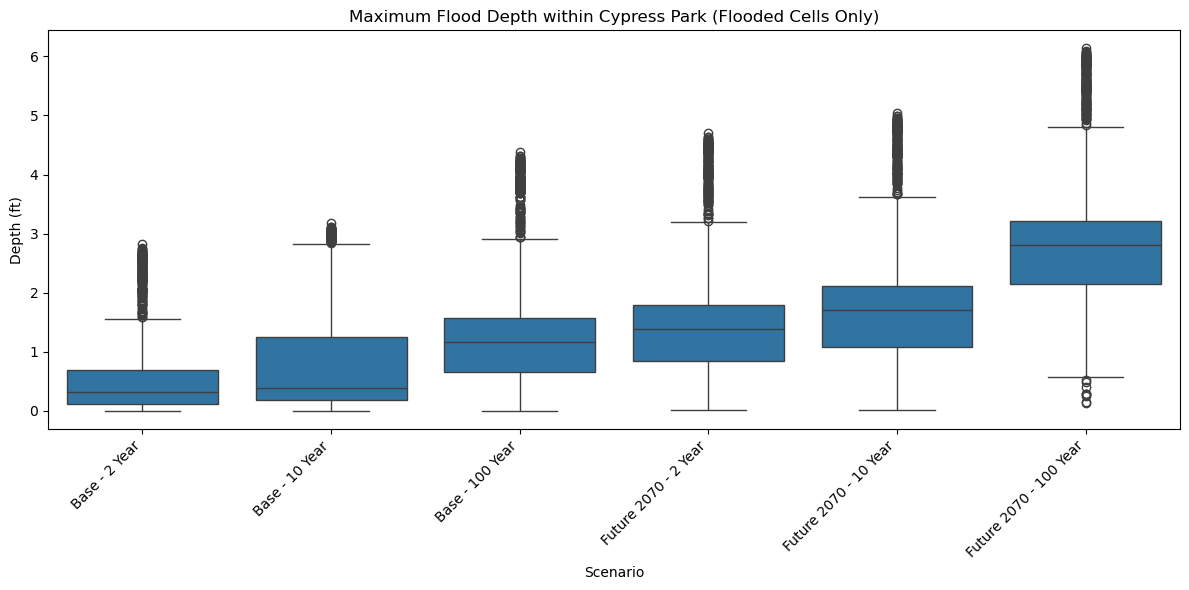

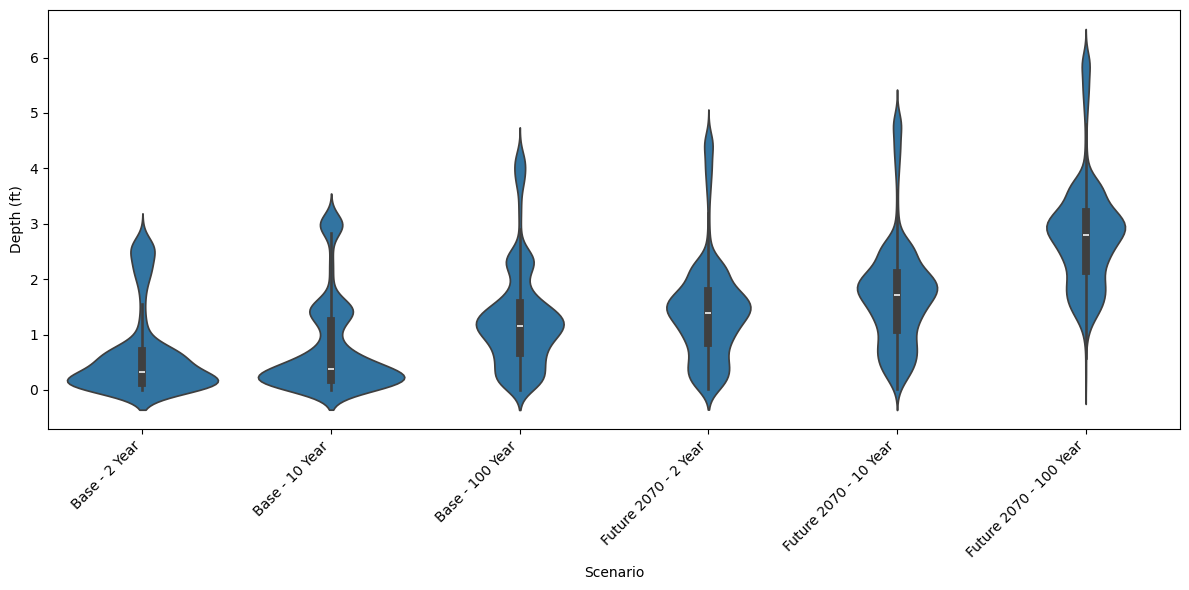

In [8]:
# Boxplot of max flood depth distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x="Raster", y="Value", data=df)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Scenario")
plt.ylabel("Depth (ft)")
plt.title("Maximum Flood Depth within Cypress Park (Flooded Cells Only)")
plt.tight_layout()
plt.show()

# Violin plot of max flood depth distribution
plt.figure(figsize=(12, 6))
sns.violinplot(x="Raster", y="Value", data=df)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Scenario")
plt.ylabel("Depth (ft)")
plt.title("")
plt.tight_layout()
plt.show()

In [9]:
# Show descriptive statistics for flood depth values by scenario
stats = df.groupby("Raster")["Value"].describe()
print(stats)

                         count      mean       std       min       25%  \
Raster                                                                   
Base - 2 Year           1384.0  0.635394  0.761340  0.001120  0.121298   
Base - 10 Year          2176.0  0.755416  0.831673  0.001235  0.181638   
Base - 100 Year         3358.0  1.290452  0.920652  0.001321  0.663915   
Future 2070 - 2 Year    3450.0  1.443133  0.927971  0.009394  0.853046   
Future 2070 - 10 Year   3605.0  1.729792  0.963382  0.013097  1.082980   
Future 2070 - 100 Year  3638.0  2.805824  0.980224  0.128013  2.150882   

                             50%       75%       max  
Raster                                                
Base - 2 Year           0.328700  0.693774  2.828202  
Base - 10 Year          0.383855  1.244561  3.187168  
Base - 100 Year         1.161228  1.570381  4.376379  
Future 2070 - 2 Year    1.386290  1.792349  4.697146  
Future 2070 - 10 Year   1.708280  2.115090  5.047136  
Future 2070 - 100 Year

C:\Users\dveronez\AppData\Local\Temp\ipykernel_53392\3049279432.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby("Raster")["Value"].describe()


In [10]:
print("Count >= 0.001 ft:", np.sum(df["Value"] >= 0.001))
print("Count == 0 exactly:", np.sum(df["Value"] <= 0.009))

Count >= 0.001 ft: 17611
Count == 0 exactly: 54


C:\Users\dveronez\AppData\Local\Temp\ipykernel_53392\2023406750.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Raster", y="Value", data=df, palette=palette)


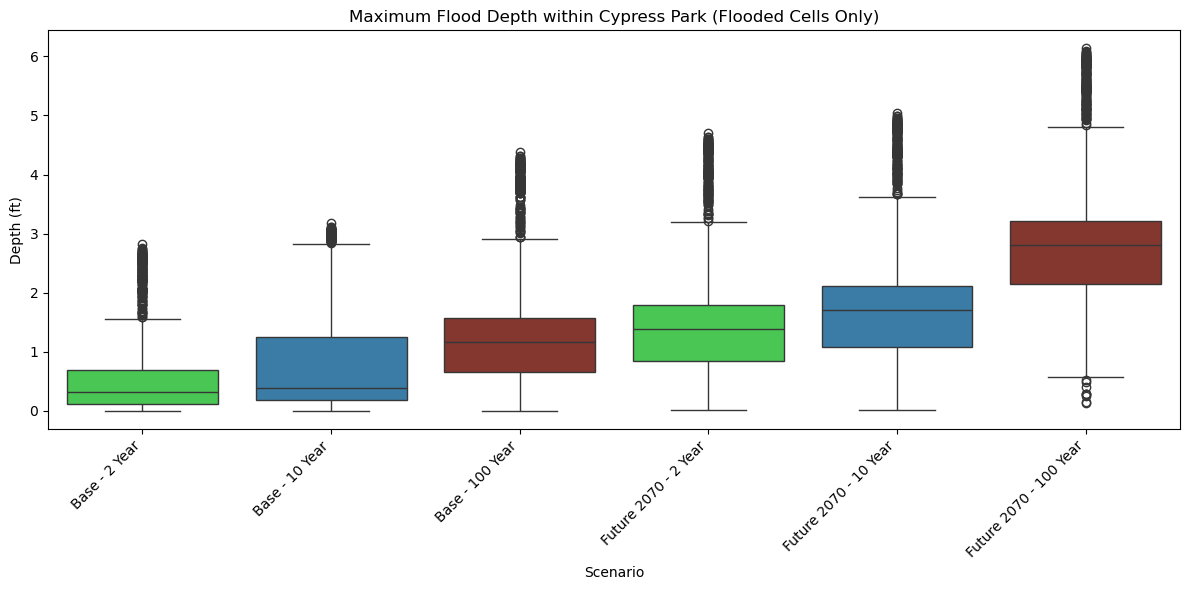

C:\Users\dveronez\AppData\Local\Temp\ipykernel_53392\2023406750.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Raster", y="Value", data=df, palette=palette)


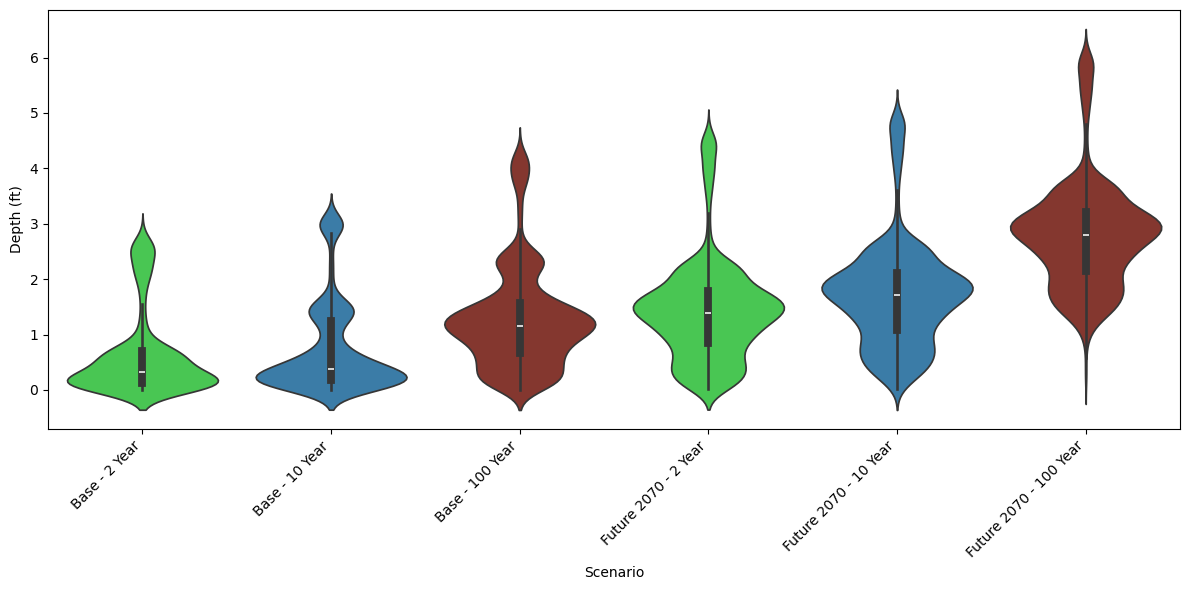

In [15]:
# Define color palette: blue for Base scenarios, red for Future scenarios
palette = {
    "Base - 2 Year": "#34db42",
    "Base - 10 Year": "#2980b9",
    "Base - 100 Year": "#922b21",
    "Future 2070 - 2 Year": "#34db42",
    "Future 2070 - 10 Year": "#2980b9",
    "Future 2070 - 100 Year": "#922b21"
}

# Boxplot of max flood depth distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x="Raster", y="Value", data=df, palette=palette)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Scenario")
plt.ylabel("Depth (ft)")
plt.title("Maximum Flood Depth within Cypress Park (Flooded Cells Only)")
plt.tight_layout()
plt.show()

# Violin plot of max flood depth distribution
plt.figure(figsize=(12, 6))
sns.violinplot(x="Raster", y="Value", data=df, palette=palette)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Scenario")
plt.ylabel("Depth (ft)")
plt.title("")
plt.tight_layout()
plt.show()

C:\Users\dveronez\AppData\Local\Temp\ipykernel_53392\3671142982.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Raster", y="Value", data=df, palette=palette, ax=ax)
C:\Users\dveronez\AppData\Local\Temp\ipykernel_53392\3671142982.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


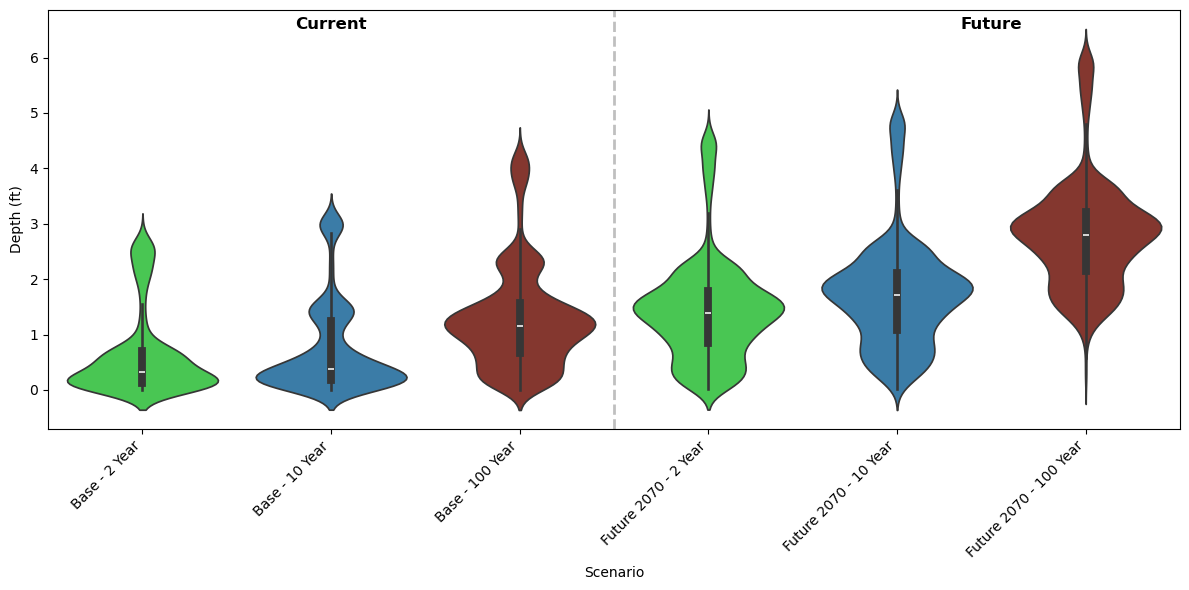

In [13]:
# Violin plot with labels distinguishing Base (Current) vs Future scenarios
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(x="Raster", y="Value", data=df, palette=palette, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("Scenario")
ax.set_ylabel("Depth (ft)")

# Add vertical line to separate Base (Current) and Future scenarios
ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=2, alpha=0.5)

# Add text labels above
ax.text(1, ax.get_ylim()[1] * 0.95, "Current", ha='center', fontsize=12, fontweight='bold')
ax.text(4.5, ax.get_ylim()[1] * 0.95, "Future", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\dveronez\AppData\Local\Temp\ipykernel_53392\1616534000.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Raster", y="Value", data=df, palette=palette, ax=ax)
C:\Users\dveronez\AppData\Local\Temp\ipykernel_53392\1616534000.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


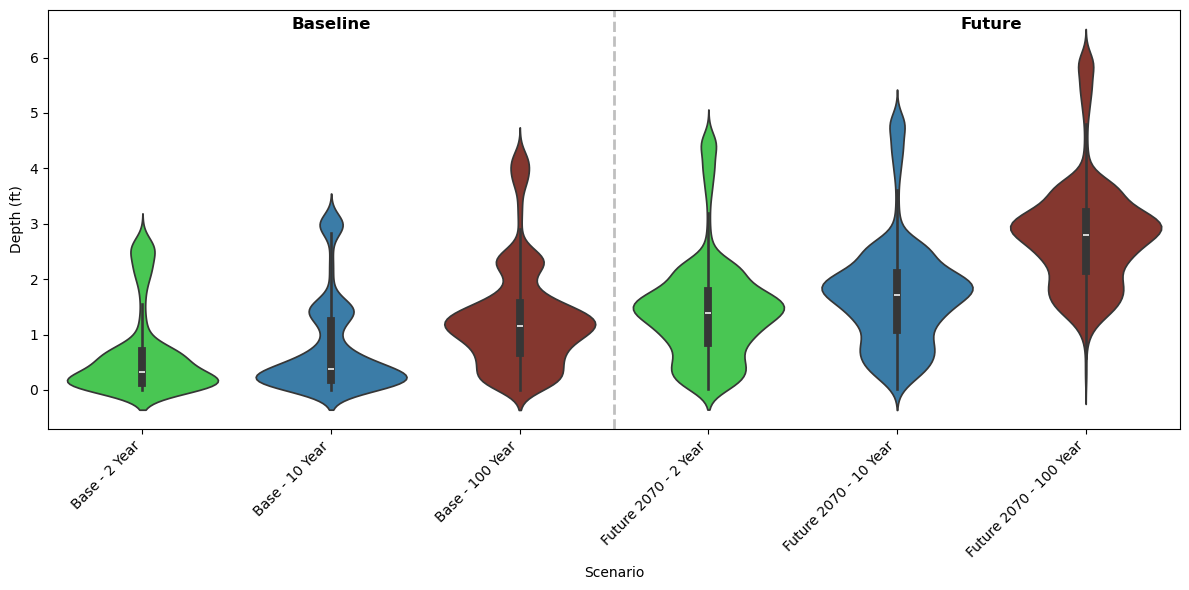

C:\Users\dveronez\AppData\Local\Temp\ipykernel_53392\1616534000.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


[Text(0, 0, '2 Year'),
 Text(1, 0, '10 Year'),
 Text(2, 0, '100 Year'),
 Text(3, 0, '2 Year'),
 Text(4, 0, '10 Year'),
 Text(5, 0, '100 Year')]

In [20]:
# Violin plot with labels distinguishing Base (Current) vs Future scenarios
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(x="Raster", y="Value", data=df, palette=palette, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("Scenario")
ax.set_ylabel("Depth (ft)")

# Add vertical line to separate Base (Current) and Future scenarios
ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=2, alpha=0.5)

# Add text labels above
ax.text(1, ax.get_ylim()[1] * 0.95, "Baseline", ha='center', fontsize=12, fontweight='bold')
ax.text(4.5, ax.get_ylim()[1] * 0.95, "Future", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Update x-axis labels to remove "Base" and "Future 2070"
labels = [label.get_text().replace("Base - ", "").replace("Future 2070 - ", "") for label in ax.get_xticklabels()]
ax.set_xticklabels(labels)